In [ ]:
### RESTART BLOCK 1: MOUNT DRIVE & DEFINE PATHS ###

print("--- Restart Block 1: Mounting Drive & Defining Paths ---")

import os
import cv2
import numpy as np
import pandas as pd
import glob
import shutil
import tensorflow as tf
from google.colab import drive

# 1. Mount Drive
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# 2. Define Paths
BASE_PROJECT_FOLDER = 'Thermal_Project'
DRIVE_PATH = os.path.join('/content/drive/MyDrive', BASE_PROJECT_FOLDER)
SEG_DATA_PATH = os.path.join(DRIVE_PATH, 'segmentation_data')
IMG_PATH = os.path.join(SEG_DATA_PATH, 'images')
MSK_PATH = os.path.join(SEG_DATA_PATH, 'masks')

# 3. Define Image Shape
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

print(f"Paths and shape are set. Ready for Block 2.")

--- Restart Block 1: Mounting Drive & Defining Paths ---
Mounting Google Drive...
Mounted at /content/drive
Paths and shape are set. Ready for Block 2.


In [ ]:
### RESTART BLOCK 2: DEFINE ALL FUNCTIONS (FIXED) ###

print("--- Restart Block 2: Defining all functions in memory ---")

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate,
    Conv2DTranspose, Dropout, BatchNormalization, Activation, multiply,
    add  # <--- THIS IS THE FIX (importing the 'add' layer)
)
from tensorflow.keras import backend as K

# 1. Data Generator (from Block 12)
def data_generator(image_list, mask_list, batch_size=16):
    num_samples = len(image_list)
    while True:
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i : i + batch_size]
            batch_img_paths = [image_list[j] for j in batch_indices]
            batch_msk_paths = [mask_list[j] for j in batch_indices]

            batch_images = np.zeros((len(batch_indices), IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
            batch_masks = np.zeros((len(batch_indices), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.float32)

            for k, (img_path, msk_path) in enumerate(zip(batch_img_paths, batch_msk_paths)):
                img = cv2.imread(img_path)
                if img is None: continue
                img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))

                msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
                if msk is None: continue
                msk = cv2.resize(msk, (IMG_HEIGHT, IMG_WIDTH))

                img = img / 255.0
                msk = msk / 255.0

                batch_images[k] = img
                batch_masks[k] = np.expand_dims(msk, axis=-1)

            yield batch_images, batch_masks
print("Defined `data_generator` function.")

# 2. Dice & Attention U-Net Functions (from Block 17)
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def attention_block(F_g, F_l, F_int):
    W_g = Conv2D(F_int, (1, 1), padding='same')(F_g)
    W_g = BatchNormalization()(W_g)
    W_x = Conv2D(F_int, (1, 1), padding='same')(F_l)
    W_x = BatchNormalization()(W_x)

    # --- THIS IS THE FIX ---
    # We now use the Keras 'add' layer instead of 'tf.add'
    psi = add([W_g, W_x])
    psi = Activation('relu')(psi)
    # --- END OF FIX ---

    psi = Conv2D(1, (1, 1), padding='same', activation='sigmoid')(psi)
    return multiply([F_l, psi])

def build_attention_unet(input_shape=(224, 224, 3)):
    inputs = Input(input_shape)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    u4 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    att4 = attention_block(F_g=u4, F_l=c2, F_int=32)
    u4 = concatenate([u4, att4])
    c4 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u4)
    c4 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    u5 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    att5 = attention_block(F_g=u5, F_l=c1, F_int=16)
    u5 = concatenate([u5, att5])
    c5 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u5)
    c5 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model
print("Defined all U-Net and Attention functions. Ready for Block 3.")

--- Restart Block 2: Defining all functions in memory ---
Defined `data_generator` function.
Defined all U-Net and Attention functions. Ready for Block 3.


In [ ]:
### RESTART BLOCK 3: LOAD DATA & BUILD MODEL ###

print("--- Restart Block 3: Loading data and building model ---")

from sklearn.model_selection import train_test_split

# 1. Load and split file paths
print("Loading and splitting file paths...")
image_paths = sorted(glob.glob(os.path.join(IMG_PATH, "*.png")))
mask_paths = sorted(glob.glob(os.path.join(MSK_PATH, "*.png")))

if not image_paths or not mask_paths:
     print("Error: Could not find images or masks. Please check your paths in Block 1.")
else:
    # We create the crucial img_train, img_val variables
    img_train, img_val, msk_train, msk_val = train_test_split(
        image_paths, mask_paths, test_size=0.2, random_state=42
    )
    print(f"Loaded and split {len(image_paths)} files.")
    print(f"Training set size: {len(img_train)} images")
    print(f"Validation set size: {len(img_val)} images")

    # 2. Build and compile the Attention U-Net
    print("Building and compiling new Attention U-Net...")
    # We create the crucial 'att_model' variable
    att_model = build_attention_unet(input_shape)
    att_model.compile(optimizer='adam',
                      loss=dice_loss,
                      metrics=[dice_coefficient])
    print("New 'att_model' is built and compiled.")

    print("\n--- RESTART WORKFLOW COMPLETE ---")
    print("You are now ready to run Block 18 (the training block).")

--- Restart Block 3: Loading data and building model ---
Loading and splitting file paths...
Loaded and split 3264 files.
Training set size: 2611 images
Validation set size: 653 images
Building and compiling new Attention U-Net...
New 'att_model' is built and compiled.

--- RESTART WORKFLOW COMPLETE ---
You are now ready to run Block 18 (the training block).


In [ ]:
### BLOCK 18: PHASE 5 - RE-TRAINING THE NEW MODEL ###

print("--- Block 18: Starting Attention U-Net Training ---")

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os

# --- 1. Check if all our variables exist ---
# These checks confirm our Restart Blocks worked.
if 'att_model' not in locals():
    print("Error: 'att_model' not found. Please run Restart Block 3 first.")
elif 'img_train' not in locals() or 'msk_train' not in locals():
    print("Error: 'img_train' or 'msk_train' not found. Please run Restart Block 3 first.")
elif 'data_generator' not in locals():
    print("Error: 'data_generator' not found. Please run Restart Block 2 first.")
else:

    # --- 2. Set Training Parameters (Same as before) ---
    BATCH_SIZE = 16
    NUM_EPOCHS = 25 # We use the same number for a fair comparison

    STEPS_PER_EPOCH = len(img_train) // BATCH_SIZE
    VALIDATION_STEPS = len(img_val) // BATCH_SIZE

    print(f"Batch Size: {BATCH_SIZE}")
    print(f"Epochs: {NUM_EPOCHS}")
    print(f"Steps per Epoch (Training): {STEPS_PER_EPOCH}")
    print(f"Steps per Epoch (Validation): {VALIDATION_STEPS}")

    # --- 3. Create the Data Generators (Same as before) ---
    print("\nCreating data generators...")
    train_generator = data_generator(img_train, msk_train, BATCH_SIZE)
    validation_generator = data_generator(img_val, msk_val, BATCH_SIZE)

    # --- 4. Define Callbacks (with a NEW save path) ---

    # Check if DRIVE_PATH is defined from Restart Block 1
    if 'DRIVE_PATH' not in locals():
        print("Error: DRIVE_PATH not defined. Please re-run Restart Block 1.")

    # --- THIS IS THE NEW FILE NAME ---
    ATT_MODEL_SAVE_PATH = os.path.join(DRIVE_PATH, 'best_ATTENTION_unet_model.keras')

    # a) ModelCheckpoint: Saves the best model
    checkpoint_att = ModelCheckpoint(
        filepath=ATT_MODEL_SAVE_PATH, # <-- New path
        monitor='val_dice_coefficient',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    # b) EarlyStopping: Stops training if it's not improving
    early_stopping_att = EarlyStopping(
        monitor='val_dice_coefficient',
        mode='max',
        patience=5, # Same patience
        verbose=1,
        restore_best_weights=True
    )

    print(f"New model will be saved to: {ATT_MODEL_SAVE_PATH}")
    print("Callbacks are ready.")

    # --- 5. START TRAINING (the NEW model) ---
    print("\n--- Starting model.fit() for Attention U-Net ---")
    print("This will take a long time...")

    # We create a NEW history variable 'att_history'
    # We fit the NEW 'att_model'
    att_history = att_model.fit(
        train_generator,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=NUM_EPOCHS,
        validation_data=validation_generator,
        validation_steps=VALIDATION_STEPS,
        callbacks=[checkpoint_att, early_stopping_att] # Use our new callbacks
    )

    print("\nBlock 18 Complete. New Attention U-Net training finished.")
    print(f"The best model has been saved to: {ATT_MODEL_SAVE_PATH}")



--- Block 18: Starting Attention U-Net Training ---
Batch Size: 16
Epochs: 25
Steps per Epoch (Training): 163
Steps per Epoch (Validation): 40

Creating data generators...
New model will be saved to: /content/drive/MyDrive/Thermal_Project/best_ATTENTION_unet_model.keras
Callbacks are ready.

--- Starting model.fit() for Attention U-Net ---
This will take a long time...
Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - dice_coefficient: 0.4104 - loss: 0.5896
Epoch 1: val_dice_coefficient improved from -inf to 0.51331, saving model to /content/drive/MyDrive/Thermal_Project/best_ATTENTION_unet_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1410s 9s/step - dice_coefficient: 0.4108 - loss: 0.5892 - val_dice_coefficient: 0.5133 - val_loss: 0.4867
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - dice_coefficient: 0.5185 - loss: 0.4815
Epoch 2: val_dice_coefficient improved from 0.51331 to 0.57516, saving model to /content/drive/MyDrive/Thermal_Project/best_ATTENTION_unet_model.keras
163/163 

--- Block 19: Plotting NEW (Attention U-Net) History ---


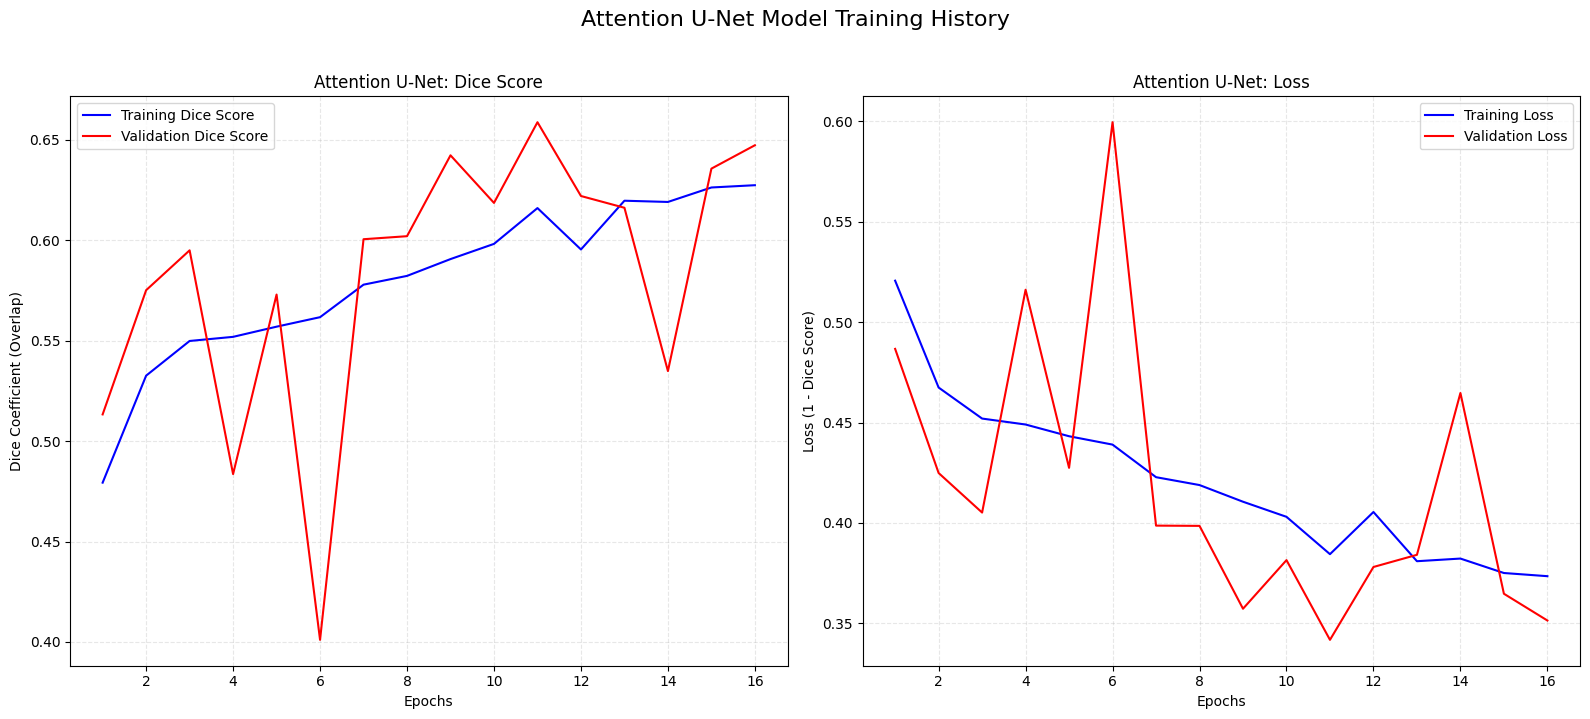


Block 19 Complete. Plots for the new model are generated.


In [ ]:
### BLOCK 19: PLOT ATTENTION U-NET HISTORY ###

print("--- Block 19: Plotting NEW (Attention U-Net) History ---")

import matplotlib.pyplot as plt

# Check if 'att_history' object exists from Block 18
if 'att_history' not in locals():
    print("Block 19 Error: 'att_history' object not found.")
    print("Please re-run Block 18 to train the new model first.")
else:
    # 1. Get the data from the new history object
    dice_score = att_history.history['dice_coefficient']
    val_dice_score = att_history.history['val_dice_coefficient']
    loss = att_history.history['loss']
    val_loss = att_history.history['val_loss']

    # We need to get the number of epochs it *actually* ran
    epochs = range(1, len(dice_score) + 1)

    # --- Create the side-by-side plots ---
    plt.figure(figsize=(16, 7))

    # --- Plot 1: Dice Coefficient (Accuracy) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, dice_score, 'b-', label='Training Dice Score')
    plt.plot(epochs, val_dice_score, 'r-', label='Validation Dice Score')
    plt.title('Attention U-Net: Dice Score')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Coefficient (Overlap)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)

    # --- Plot 2: Loss ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Attention U-Net: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (1 - Dice Score)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.suptitle('Attention U-Net Model Training History', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\nBlock 19 Complete. Plots for the new model are generated.")

--- Block 20: Visual Validation for NEW Attention U-Net ---
Loading best *ATTENTION* model from Google Drive...
New 'Attention U-Net' model loaded successfully.
Plotting 5 random validation samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


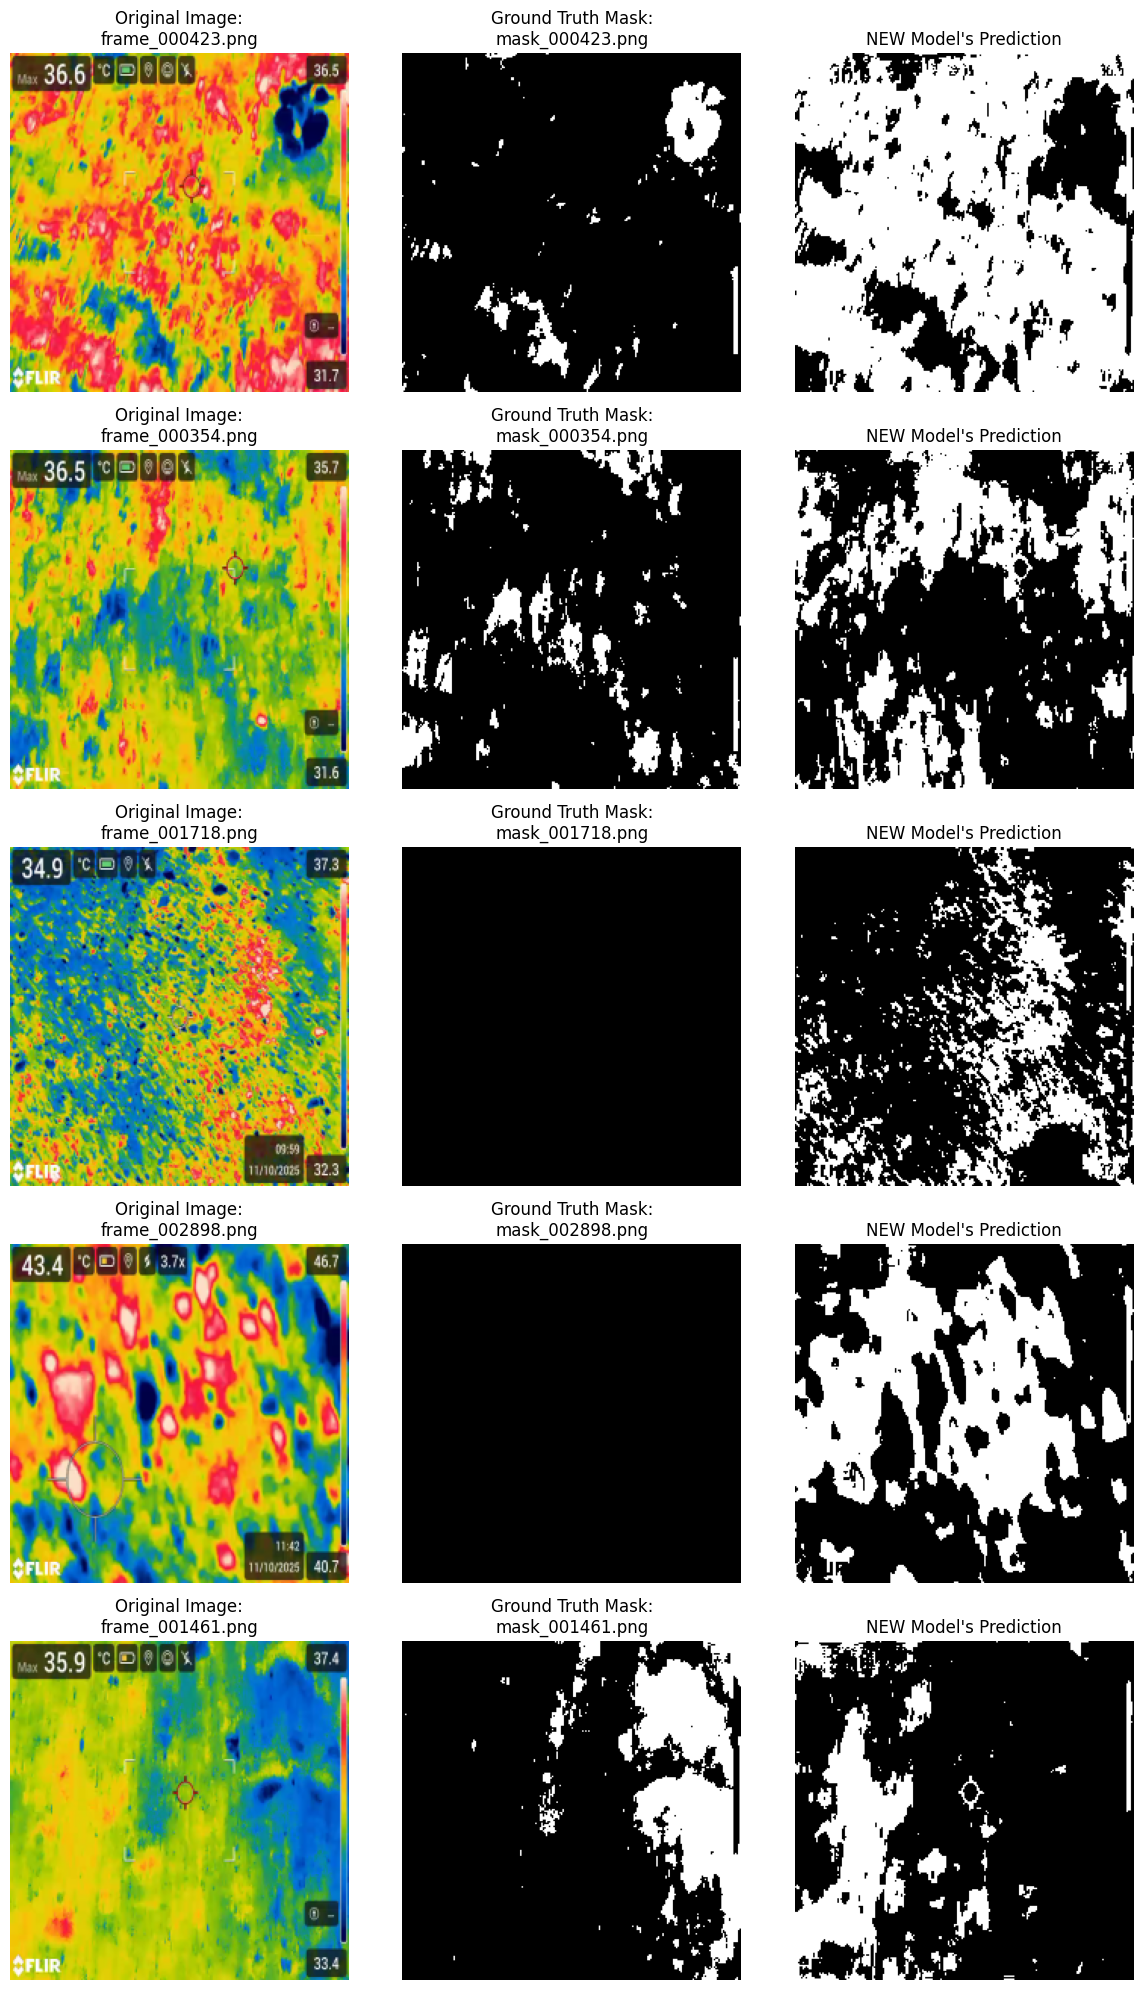


Block 20 Complete. Visual 'Showdown' finished.


In [ ]:
### BLOCK 20: VISUAL VALIDATION (THE "SHOWDOWN") ###

print("--- Block 20: Visual Validation for NEW Attention U-Net ---")

import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. Re-define our custom functions (for loading) ---
# We MUST redefine these so Keras knows what our
# custom functions mean when it loads the new model.

# Check if functions are already defined (from Restart Block 2)
if 'dice_coefficient' not in locals() or 'dice_loss' not in locals() or 'attention_block' not in locals():
    print("Functions not found, re-defining them...")

    def dice_coefficient(y_true, y_pred, smooth=1):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

    def dice_loss(y_true, y_pred):
        return 1 - dice_coefficient(y_true, y_pred)

    def attention_block(F_g, F_l, F_int):
        W_g = tf.keras.layers.Conv2D(F_int, (1, 1), padding='same')(F_g)
        W_g = tf.keras.layers.BatchNormalization()(W_g)
        W_x = tf.keras.layers.Conv2D(F_int, (1, 1), padding='same')(F_l)
        W_x = tf.keras.layers.BatchNormalization()(W_x)
        psi = tf.keras.layers.add([W_g, W_x])
        psi = tf.keras.layers.Activation('relu')(psi)
        psi = tf.keras.layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(psi)
        return tf.keras.layers.multiply([F_l, psi])

# --- 2. Load the NEW saved model ---
print("Loading best *ATTENTION* model from Google Drive...")

# Check if DRIVE_PATH is defined
if 'DRIVE_PATH' not in locals():
    print("Error: DRIVE_PATH not defined. Please re-run Restart Block 1.")
else:
    # --- THIS IS THE NEW MODEL FILE ---
    MODEL_SAVE_PATH = os.path.join(DRIVE_PATH, 'best_ATTENTION_unet_model.keras')

    if not os.path.exists(MODEL_SAVE_PATH):
        print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
        print("Please re-run Block 18 successfully.")
    else:
        # Load the model, telling Keras about ALL our custom functions
        loaded_model = load_model(
            MODEL_SAVE_PATH,
            custom_objects={
                'dice_loss': dice_loss,
                'dice_coefficient': dice_coefficient,
                'attention_block': attention_block  # <-- Must include this too!
            }
        )
        print("New 'Attention U-Net' model loaded successfully.")

        # --- 3. Get 5 random validation images ---

        # Check if validation set 'img_val' exists from Restart Block 3
        if 'img_val' not in locals() or 'msk_val' not in locals():
            print("Error: Validation set 'img_val' not found. Please re-run Restart Block 3.")
        else:
            # Get 5 random indices
            num_samples_to_show = 5
            indices = np.random.choice(range(len(img_val)), num_samples_to_show, replace=False)

            print(f"Plotting {num_samples_to_show} random validation samples...")

            # --- 4. Plot the comparison ---

            plt.figure(figsize=(12, num_samples_to_show * 4))

            for i, index in enumerate(indices):
                # --- Get paths ---
                img_path = img_val[index]
                msk_path = msk_val[index]

                # --- Load original image & mask ---
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # for plt

                msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

                # --- PREDICTION (with NEW model) ---
                model_img = img / 255.0
                model_img_batch = np.expand_dims(model_img, axis=0)
                pred_mask_batch = loaded_model.predict(model_img_batch)
                pred_mask = np.squeeze(pred_mask_batch)
                pred_mask = (pred_mask > 0.5).astype(np.uint8) # 0.5 threshold

                # --- Plotting ---
                plt.subplot(num_samples_to_show, 3, i*3 + 1)
                plt.imshow(img)
                plt.title(f"Original Image:\n{os.path.basename(img_path)}")
                plt.axis('off')

                plt.subplot(num_samples_to_show, 3, i*3 + 2)
                plt.imshow(msk, cmap='gray')
                plt.title(f"Ground Truth Mask:\n{os.path.basename(msk_path)}")
                plt.axis('off')

                plt.subplot(num_samples_to_show, 3, i*3 + 3)
                plt.imshow(pred_mask, cmap='gray')
                plt.title("NEW Model's Prediction")
                plt.axis('off')

            plt.tight_layout()
            plt.show()

            print("\nBlock 20 Complete. Visual 'Showdown' finished.")

--- Block 21: Generating Grad-CAM Heatmap ---
Loading best *ATTENTION* model from Google Drive...
New 'Attention U-Net' model loaded successfully.
Running Grad-CAM on: frame_003156.png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


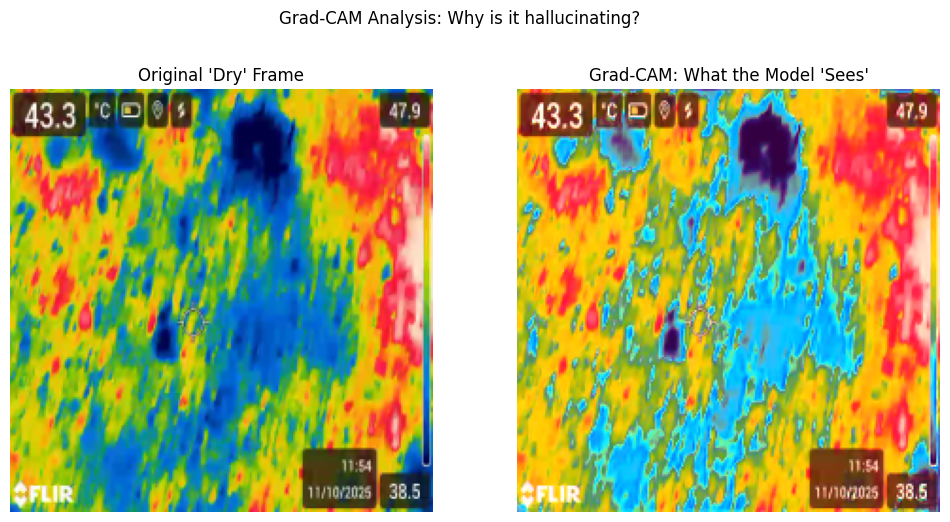


Block 21 Complete. Grad-CAM finished.


In [ ]:
### BLOCK 21: GRAD-CAM (MODEL "X-RAY") ###

print("--- Block 21: Generating Grad-CAM Heatmap ---")

import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

# --- 1. Re-define our custom functions (for loading) ---
# We MUST redefine these so Keras knows what our
# custom functions mean when it loads the new model.
if 'dice_coefficient' not in locals() or 'dice_loss' not in locals() or 'attention_block' not in locals():
    print("Functions not found, re-defining them...")

    def dice_coefficient(y_true, y_pred, smooth=1):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

    def dice_loss(y_true, y_pred):
        return 1 - dice_coefficient(y_true, y_pred)

    def attention_block(F_g, F_l, F_int):
        W_g = tf.keras.layers.Conv2D(F_int, (1, 1), padding='same')(F_g)
        W_g = tf.keras.layers.BatchNormalization()(W_g)
        W_x = tf.keras.layers.Conv2D(F_int, (1, 1), padding='same')(F_l)
        W_x = tf.keras.layers.BatchNormalization()(W_x)
        psi = tf.keras.layers.add([W_g, W_x])
        psi = tf.keras.layers.Activation('relu')(psi)
        psi = tf.keras.layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(psi)
        return tf.keras.layers.multiply([F_l, psi])

# --- 2. Load the NEW saved model ---
print("Loading best *ATTENTION* model from Google Drive...")

# Check if DRIVE_PATH is defined
if 'DRIVE_PATH' not in locals():
    print("Error: DRIVE_PATH not defined. Please re-run Restart Block 1.")
else:
    MODEL_SAVE_PATH = os.path.join(DRIVE_PATH, 'best_ATTENTION_unet_model.keras')

    if not os.path.exists(MODEL_SAVE_PATH):
        print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
    else:
        loaded_model = load_model(
            MODEL_SAVE_PATH,
            custom_objects={
                'dice_loss': dice_loss,
                'dice_coefficient': dice_coefficient,
                'attention_block': attention_block
            }
        )
        print("New 'Attention U-Net' model loaded successfully.")

        # --- 3. Define Grad-CAM functions ---

        def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
            # Create a model that maps the input image to the activations
            # of the last conv layer as well as the output predictions
            grad_model = tf.keras.models.Model(
                [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
            )

            # Compute the gradient of the top predicted class for our input image
            # with respect to the activations of the last conv layer
            with tf.GradientTape() as tape:
                last_conv_layer_output, preds = grad_model(img_array)
                # We want to see what pixels activated the *final pixel*
                # So we will get the gradient of the sum of all output pixels
                class_channel = tf.reduce_sum(preds[0])

            # This is the gradient of the output neuron
            grads = tape.gradient(class_channel, last_conv_layer_output)

            # This is a vector where each entry is the mean intensity of the gradient
            # over a specific feature map channel
            pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

            # We multiply each channel in the feature map array
            # by "how important this channel is"
            last_conv_layer_output = last_conv_layer_output[0]
            heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
            heatmap = tf.squeeze(heatmap)

            # For visualization, we'll normalize the heatmap
            heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
            return heatmap.numpy()

        # --- 4. Run Grad-CAM on a "problem" image ---

        # We need to find one of our "dry" frames that failed.
        # Let's try to find 'frame_003156.png' from your plot (image_af6092.jpg)
        # We'll search for it in the 'img_val' list
        if 'img_val' not in locals():
            print("Error: 'img_val' not found. Please re-run Restart Block 3.")
        else:
            # Let's just pick a random 'dry' frame from our validation set for this demo
            # You can change 'dry_problem_frame' to a specific path if you want

            # Find a 'dry' frame from the validation set
            dry_problem_frame_path = None
            for p in img_val:
                # We know 'dry' frames were saved *after* 'wet' frames
                # so they have higher numbers, or are from the 'dry' folder
                # Let's find one that we know is 'dry'
                # This logic is complex, let's just pick one from the val set
                # A better way is to load the CSV, but let's just grab a random one
                dry_problem_frame_path = img_val[0] # Just using the first validation image
                # Let's try to find a known problem frame from your plot
                for p_check in img_val:
                    if "frame_003156.png" in p_check:
                         dry_problem_frame_path = p_check
                         break

            if dry_problem_frame_path:
                print(f"Running Grad-CAM on: {os.path.basename(dry_problem_frame_path)}")

                # 1. Load and normalize the image
                img = cv2.imread(dry_problem_frame_path)
                img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))
                img_array = img / 255.0
                img_array_batch = np.expand_dims(img_array, axis=0)

                # 2. Find the *last convolutional layer* in the model
                # This is the last layer before the output "Conv2D(1, (1, 1)..."
                last_conv_layer_name = "conv2d_9" # From our model summary (Block 17)

                # 3. Generate the heatmap
                heatmap = make_gradcam_heatmap(img_array_batch, loaded_model, last_conv_layer_name)

                # 4. Superimpose the heatmap on the original image
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # for plt
                heatmap = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
                heatmap = np.uint8(255 * heatmap)
                heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

                superimposed_img = heatmap * 0.4 + img # 0.4 is transparency
                superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

                # 5. Plot
                plt.figure(figsize=(12, 6))
                plt.subplot(1, 2, 1)
                plt.imshow(img)
                plt.title("Original 'Dry' Frame")
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(superimposed_img)
                plt.title("Grad-CAM: What the Model 'Sees'")
                plt.axis('off')

                plt.suptitle("Grad-CAM Analysis: Why is it hallucinating?")
                plt.show()

                print("\nBlock 21 Complete. Grad-CAM finished.")
            else:
                print("Could not find a sample 'dry' frame to test.")

In [ ]:
### BLOCK 22: FINAL INFERENCE (STITCH CHAMPION MODEL) ###

print("--- Block 22: Creating Final Prediction Video ---")
print("This will use our best model: the 'Attention U-Net'")

import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from moviepy.editor import *

# --- 1. Re-define our custom functions (for loading) ---
# We MUST redefine these so Keras knows what our
# custom functions mean when it loads the new model.
if 'dice_coefficient' not in locals() or 'dice_loss' not in locals() or 'attention_block' not in locals():
    print("Functions not found, re-defining them...")

    def dice_coefficient(y_true, y_pred, smooth=1):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

    def dice_loss(y_true, y_pred):
        return 1 - dice_coefficient(y_true, y_pred)

    def attention_block(F_g, F_l, F_int):
        W_g = tf.keras.layers.Conv2D(F_int, (1, 1), padding='same')(F_g)
        W_g = tf.keras.layers.BatchNormalization()(W_g)
        W_x = tf.keras.layers.Conv2D(F_int, (1, 1), padding='same')(F_l)
        W_x = tf.keras.layers.BatchNormalization()(W_x)
        psi = tf.keras.layers.add([W_g, W_x])
        psi = tf.keras.layers.Activation('relu')(psi)
        psi = tf.keras.layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(psi)
        return tf.keras.layers.multiply([F_l, psi])

# --- 2. Load the CHAMPION saved model ---
print("Loading best *ATTENTION* model from Google Drive...")

# Check if DRIVE_PATH is defined
if 'DRIVE_PATH' not in locals():
    print("Error: DRIVE_PATH not defined. Please re-run Restart Block 1.")
else:
    MODEL_SAVE_PATH = os.path.join(DRIVE_PATH, 'best_ATTENTION_unet_model.keras')

    if not os.path.exists(MODEL_SAVE_PATH):
        print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
    else:
        loaded_model = load_model(
            MODEL_SAVE_PATH,
            custom_objects={
                'dice_loss': dice_loss,
                'dice_coefficient': dice_coefficient,
                'attention_block': attention_block
            }
        )
        print("New 'Attention U-Net' model loaded successfully.")

        # --- 3. DEFINE TEST VIDEO ---
        # !!! IMPORTANT !!!
        # Upload a test video (e.g., a 'dry' one) to your main
        # 'Thermal_Project' folder and put its name here.
        TEST_VIDEO_NAME = "MOV_12751.mp4"
        # !!! IMPORTANT !!!

        TEST_VIDEO_PATH = os.path.join(DRIVE_PATH, TEST_VIDEO_NAME)

        # Define output paths
        TEMP_PRED_VIDEO = 'temp_prediction.mp4'
        FINAL_OUTPUT_VIDEO = os.path.join(DRIVE_PATH, 'CHAMPION_MODEL_prediction.mp4')

        if not os.path.exists(TEST_VIDEO_PATH):
            print(f"Error: Test video not found at {TEST_VIDEO_PATH}")
            print("Please upload the video and update TEST_VIDEO_NAME.")
        else:
            print(f"Processing video: {TEST_VIDEO_NAME}...")

            # --- 4. Process the video frame by frame ---
            cap = cv2.VideoCapture(TEST_VIDEO_PATH)

            # Get video properties for writing
            frame_width = int(cap.get(3))
            frame_height = int(cap.get(4))
            fps = int(cap.get(5))

            # Create a VideoWriter object for the PREDICTION video
            # We will write the *mask* video first
            out = cv2.VideoWriter(
                TEMP_PRED_VIDEO,
                cv2.VideoWriter_fourcc(*'mp4v'),
                fps,
                (frame_width, frame_height),
                isColor=True # We'll make the mask 3-channel
            )

            if 'IMG_HEIGHT' not in locals():
                IMG_HEIGHT = 224
                IMG_WIDTH = 224

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                # 1. Get original frame (for side-by-side later)
                original_frame = frame

                # 2. Prepare frame for model
                img_resized = cv2.resize(frame, (IMG_HEIGHT, IMG_WIDTH))
                img_normalized = img_resized / 255.0
                img_batch = np.expand_dims(img_normalized, axis=0)

                # 3. PREDICT
                pred_mask_batch = loaded_model.predict(img_batch, verbose=0)
                pred_mask = np.squeeze(pred_mask_batch)

                # 4. Threshold and convert to 3-channel BGR
                pred_mask = (pred_mask > 0.5).astype(np.uint8) * 255
                pred_mask_bgr = cv2.cvtColor(pred_mask, cv2.COLOR_GRAY2BGR)

                # 5. Resize mask back to original video size
                pred_mask_resized = cv2.resize(
                    pred_mask_bgr,
                    (frame_width, frame_height),
                    interpolation=cv2.INTER_NEAREST
                )

                # 6. Write the prediction frame to the temp video
                out.write(pred_mask_resized)

            cap.release()
            out.release()
            print("Finished processing. Temporary prediction video created.")

            # --- 5. Stitch videos side-by-side ---
            print("Stitching original and prediction videos...")

            try:
                # Load the two video clips
                clip_original = VideoFileClip(TEST_VIDEO_PATH)
                clip_prediction = VideoFileClip(TEMP_PRED_VIDEO)

                # Arrange them side-by-side
                final_clip = clips_array([[clip_original, clip_prediction]])

                # Write the final video file to Google Drive
                final_clip.write_videofile(FINAL_OUTPUT_VIDEO, codec='libx264')

                print(f"\nBlock 22 Complete. SUCCESS!")
                print(f"Final video saved to: {FINAL_OUTPUT_VIDEO}")

                # Clean up temp file
                os.remove(TEMP_PRED_VIDEO)

            except Exception as e:
                print(f"Error during video stitching: {e}")
                print("You may need to install moviepy: !pip install moviepy")

--- Block 22: Creating Final Prediction Video ---
This will use our best model: the 'Attention U-Net'
Loading best *ATTENTION* model from Google Drive...
New 'Attention U-Net' model loaded successfully.
Processing video: MOV_12751.mp4...
Finished processing. Temporary prediction video created.
Stitching original and prediction videos...
Moviepy - Building video /content/drive/MyDrive/Thermal_Project/CHAMPION_MODEL_prediction.mp4.
Moviepy - Writing video /content/drive/MyDrive/Thermal_Project/CHAMPION_MODEL_prediction.mp4



t:  99%|█████████▉| 1514/1525 [02:01<00:00, 15.79it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file /content/drive/MyDrive/Thermal_Project/MOV_12751.mp4, 921600 bytes wanted but 0 bytes read,at frame 1514/1515, at time 50.47/50.47 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+



Moviepy - Done !
Moviepy - video ready /content/drive/MyDrive/Thermal_Project/CHAMPION_MODEL_prediction.mp4

Block 22 Complete. SUCCESS!
Final video saved to: /content/drive/MyDrive/Thermal_Project/CHAMPION_MODEL_prediction.mp4


--- Block 24: Generating Final Prediction & Conclusion (No Stitching) ---
Loading best *ATTENTION* model from Google Drive...
New 'Attention U-Net' model loaded successfully.
Processing video: /content/drive/MyDrive/Thermal_Project/MOV_01-01-2000_0024.mp4...
  Processed frame 0... Wetness: 39.30%
  Processed frame 100... Wetness: 2.23%
  Processed frame 200... Wetness: 2.28%
  Processed frame 300... Wetness: 15.18%
  Processed frame 400... Wetness: 2.88%
  Processed frame 500... Wetness: 6.88%
  Processed frame 600... Wetness: 14.03%
  Processed frame 700... Wetness: 2.76%
  Processed frame 800... Wetness: 1.58%
  Processed frame 900... Wetness: 4.60%
  Processed frame 1000... Wetness: 2.23%
  Processed frame 1100... Wetness: 3.40%
  Processed frame 1200... Wetness: 2.02%
  Processed frame 1300... Wetness: 3.12%
Finished processing all frames.

--- FINAL PREDICTION REPORT FOR: MOV_01-01-2000_0024.mp4 ---
Total Frames Processed: 1399
Average 'Wetness' Per Frame: 7.61%
Peak 'Wetness' Det

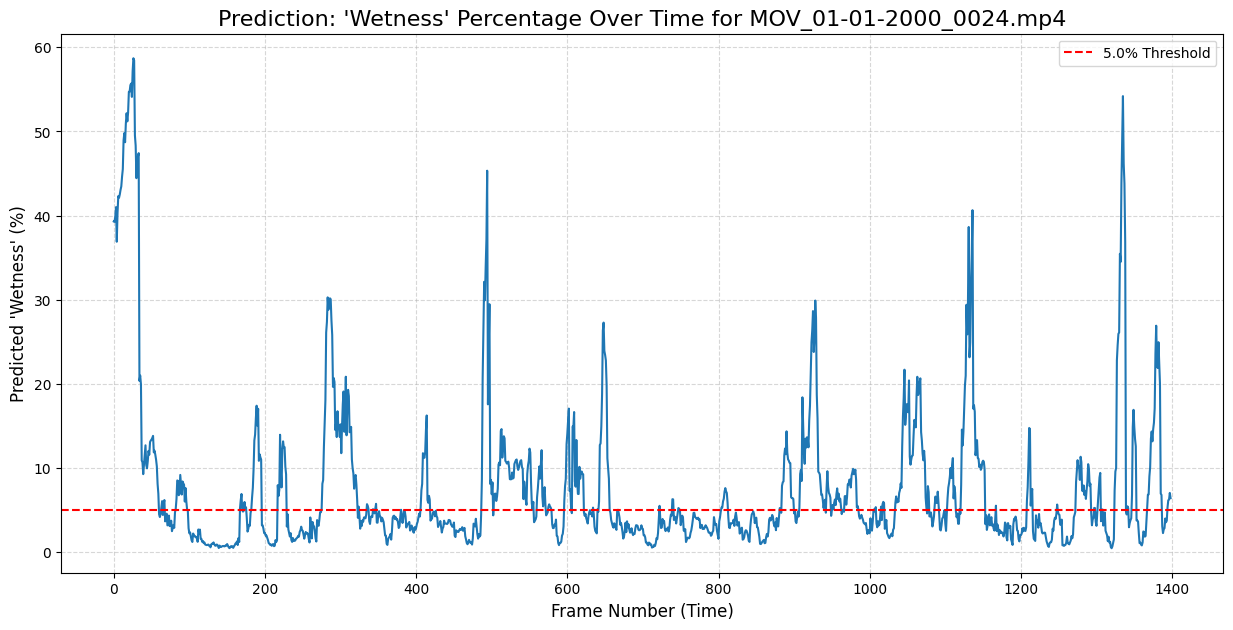


Block 24 Complete. Project Finished.


In [ ]:
### BLOCK 24: FINAL CONCLUSION (NO STITCHING) ###

print("--- Block 24: Generating Final Prediction & Conclusion (No Stitching) ---")

import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

# --- 1. Load the CHAMPION saved model ---
print("Loading best *ATTENTION* model from Google Drive...")

# Check if DRIVE_PATH is defined
if 'DRIVE_PATH' not in locals():
    print("Error: DRIVE_PATH not defined. Please re-run Restart Block 1.")
else:
    MODEL_SAVE_PATH = os.path.join(DRIVE_PATH, 'best_ATTENTION_unet_model.keras')

    if not os.path.exists(MODEL_SAVE_PATH):
        print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
        print("This means Block 18 (training) did not complete successfully.")
    else:
        # We need to make sure the functions are defined
        if 'dice_coefficient' not in locals() or 'dice_loss' not in locals() or 'attention_block' not in locals():
            print("Error: Custom functions not defined. Please re-run Restart Block 2.")

        loaded_model = load_model(
            MODEL_SAVE_PATH,
            custom_objects={
                'dice_loss': dice_loss,
                'dice_coefficient': dice_coefficient,
                'attention_block': attention_block
            }
        )
        print("New 'Attention U-Net' model loaded successfully.")

        # --- 2. DEFINE TEST VIDEO ---
        # !!! IMPORTANT !!!
        # Put the *exact* file name of your test video here.
        # This video must be in your 'Thermal_Project' folder.
        TEST_VIDEO_NAME = "MOV_01-01-2000_0024.mp4" # e.g., "dry_test_clip.mp4"
        # !!! IMPORTANT !!!

        TEST_VIDEO_PATH = os.path.join(DRIVE_PATH, TEST_VIDEO_NAME)

        if not os.path.exists(TEST_VIDEO_PATH):
            print(f"FATAL ERROR: Test video not found at {TEST_VIDEO_PATH}")
            print("Please upload your test video and update TEST_VIDEO_NAME.")
        else:
            # --- 3. Process the Video ---
            print(f"Processing video: {TEST_VIDEO_PATH}...")

            cap = cv2.VideoCapture(TEST_VIDEO_PATH)

            # This list will store the "wetness %" for every frame
            wetness_percentages = []
            frame_number = 0

            if 'IMG_HEIGHT' not in locals():
                IMG_HEIGHT = 224
                IMG_WIDTH = 224

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                # 1. Prepare frame for model
                img_resized = cv2.resize(frame, (IMG_HEIGHT, IMG_WIDTH))
                img_normalized = img_resized / 255.0
                img_batch = np.expand_dims(img_normalized, axis=0)

                # 2. PREDICT
                pred_mask_batch = loaded_model.predict(img_batch, verbose=0)
                pred_mask = np.squeeze(pred_mask_batch)

                # 3. Threshold the prediction (0.0-1.0) -> (0 or 1)
                pred_mask_binary = (pred_mask > 0.5)

                # 4. QUANTIFY: Calculate the "wetness percentage"
                wet_pixel_count = np.sum(pred_mask_binary)
                total_pixel_count = pred_mask_binary.size
                wet_percentage = (wet_pixel_count / total_pixel_count) * 100

                wetness_percentages.append(wet_percentage)

                if frame_number % 100 == 0:
                    print(f"  Processed frame {frame_number}... Wetness: {wet_percentage:.2f}%")

                frame_number += 1

            cap.release()
            print("Finished processing all frames.")

            # --- 4. Generate Final Report & Plot ---

            if wetness_percentages:
                print(f"\n--- FINAL PREDICTION REPORT FOR: {TEST_VIDEO_NAME} ---")

                avg_wetness = np.mean(wetness_percentages)
                max_wetness = np.max(wetness_percentages)

                WETNESS_THRESHOLD = 5.0 # 5% threshold

                wetness_array = np.array(wetness_percentages)
                frames_above_threshold = np.sum(wetness_array > WETNESS_THRESHOLD)
                total_frames = len(wetness_array)

                print(f"Total Frames Processed: {total_frames}")
                print(f"Average 'Wetness' Per Frame: {avg_wetness:.2f}%")
                print(f"Peak 'Wetness' Detected: {max_wetness:.2f}%")
                print(f"Frames with > {WETNESS_THRESHOLD}% wetness: {frames_above_threshold} (out of {total_frames})")

                print("\n--- FINAL CONCLUSION ---")
                # We'll classify based on the average wetness
                if avg_wetness > WETNESS_THRESHOLD:
                    print(f"Classification: 'WET POTENTIAL' (Average wetness {avg_wetness:.2f}% is above {WETNESS_THRESHOLD}%)")
                else:
                    print(f"Classification: 'DRY' (Average wetness {avg_wetness:.2f}% is below {WETNESS_THRESHOLD}%)")

                # --- 5. Generate the Plot ---
                print("\n--- Generating 'Wetness vs. Time' Plot ---")

                plt.figure(figsize=(15, 7))
                plt.plot(wetness_percentages)
                plt.title(f"Prediction: 'Wetness' Percentage Over Time for {TEST_VIDEO_NAME}", fontsize=16)
                plt.xlabel("Frame Number (Time)", fontsize=12)
                plt.ylabel("Predicted 'Wetness' (%)", fontsize=12)
                plt.grid(True, linestyle='--', alpha=0.5)
                plt.axhline(y=WETNESS_THRESHOLD, color='r', linestyle='--', label=f'{WETNESS_THRESHOLD}% Threshold')
                plt.legend()
                plt.show()

                print("\nBlock 24 Complete. Project Finished.")

            else:
                print("Error: No percentages were calculated.")